# Egress, Inc. — Ski Jacket Production Simulation
### Monte Carlo analysis: optimal production quantity under demand uncertainty

**Model logic (from the @RISK template):**

| Variable | Formula |
|---|---|
| Demand | `Normal(mean=12,000, std=3,497)` — simulated |
| Revenue | `selling_price × min(production_Q, demand)` |
| Salvage value | `salvage_price × max(production_Q − demand, 0)` |
| Variable cost | `variable_cost × production_Q` |
| **Profit** | `Revenue + Salvage − Variable cost − Fixed cost` |

We sweep `production_Q` from **5,000 to 20,000** (step 500) and run **10,000 simulations** per quantity.


In [3]:
import warnings; warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot  as plt
import matplotlib.ticker  as mticker

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi"       : 130,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "figure.facecolor" : "#FAFAFA",
    "axes.facecolor"   : "#FAFAFA",
})

RNG = np.random.default_rng(seed=42)
print("Libraries loaded ✓")


Libraries loaded ✓


In [4]:
# ── Model parameters (from slide) ────────────────────────────────────────────
UNIT_VARIABLE_COST = 80
UNIT_SELLING_PRICE = 100
UNIT_SALVAGE_VALUE = 30
FIXED_COST         = 100_000

MEAN_DEMAND  = 12_000
STDEV_DEMAND = 3_497

# Sweep range for production quantity
Q_VALUES = np.arange(5_000, 20_500, 500)   # 5000 → 20000 in steps of 500

N_SIMS = 10_000   # simulations per production quantity

print(f"Production quantities to test : {len(Q_VALUES)}  ({Q_VALUES[0]:,} → {Q_VALUES[-1]:,})")
print(f"Simulations per quantity      : {N_SIMS:,}")
print(f"Total simulation runs         : {len(Q_VALUES) * N_SIMS:,}")


Production quantities to test : 31  (5,000 → 20,000)
Simulations per quantity      : 10,000
Total simulation runs         : 310,000


In [5]:
# ── Vectorised Monte Carlo sweep ─────────────────────────────────────────────
# Draw ALL demand scenarios at once: shape (N_SIMS,)
# Same demand draws reused across every Q — apples-to-apples comparison
demand_draws = RNG.normal(loc=MEAN_DEMAND, scale=STDEV_DEMAND, size=N_SIMS)
demand_draws = np.maximum(demand_draws, 0)   # demand can't be negative

def simulate_profit(Q: float, demand: np.ndarray) -> np.ndarray:
    """Vectorised profit for production quantity Q over all demand scenarios."""
    return (
        pd.Series(demand)
        .pipe(lambda d: (
            UNIT_SELLING_PRICE * np.minimum(Q, d)          # revenue
          + UNIT_SALVAGE_VALUE * np.maximum(Q - d, 0)      # salvage
          - UNIT_VARIABLE_COST * Q                         # variable cost
          - FIXED_COST                                     # fixed cost
        ))
    )

# Build results via method chaining
results = (
    pd.DataFrame({"Q": Q_VALUES})
    .assign(
        profits   = lambda df: df["Q"].apply(
                        lambda q: simulate_profit(q, demand_draws).to_numpy()),
        mean      = lambda df: df["profits"].apply(np.mean),
        median    = lambda df: df["profits"].apply(np.median),
        p5       = lambda df: df["profits"].apply(lambda x: np.percentile(x, 5)),
        p25       = lambda df: df["profits"].apply(lambda x: np.percentile(x, 25)),
        p75       = lambda df: df["profits"].apply(lambda x: np.percentile(x, 75)),
        p95       = lambda df: df["profits"].apply(lambda x: np.percentile(x, 95)),
        prob_loss = lambda df: df["profits"].apply(lambda x: (x < 0).mean()),
        prob_profit_gt_0   = lambda df: df["profits"].apply(lambda x: (x > 0).mean()),
    )
)

best_mean   = results.loc[results["mean"].idxmax(), "Q"]
best_median = results.loc[results["median"].idxmax(), "Q"]
print(f"Optimal Q (max mean profit)   : {best_mean:,.0f} units")
print(f"Optimal Q (max median profit) : {best_median:,.0f} units")


Optimal Q (max mean profit)   : 10,000 units
Optimal Q (max median profit) : 12,000 units


In [6]:
# ── Summary statistics table ──────────────────────────────────────────────────
(
    results
    .drop(columns="profits")
    .assign(
        Q         = lambda df: df["Q"].map("{:,.0f}".format),
        mean      = lambda df: df["mean"].map("${:,.0f}".format),
        median    = lambda df: df["median"].map("${:,.0f}".format),
        p5       = lambda df: df["p5"].map("${:,.0f}".format),
        p25       = lambda df: df["p25"].map("${:,.0f}".format),
        p75       = lambda df: df["p75"].map("${:,.0f}".format),
        p95       = lambda df: df["p95"].map("${:,.0f}".format),
        prob_loss = lambda df: df["prob_loss"].map("{:.1%}".format),
    )
    .rename(columns={
        "Q": "Production Q", "mean": "Mean Profit", "median": "Median",
        "p5": "P5", "p25": "P25", "p75": "P75", "p95": "P95",
        "prob_loss": "P(Loss)", "prob_profit_gt_0": "P(Profit>0)"
    })
    .set_index("Production Q")
)


,Mean Profit,Median,P5,P25,P75,P95,P(Loss),P(Profit>0)
Production Q,,,,,,,,
"5,000","$-2,273",$0,$0,$0,$0,$0,2.3%,0.0000
"5,500","$6,770","$10,000","$10,000","$10,000","$10,000","$10,000",2.9%,0.9714
"6,000","$15,399","$20,000","$20,000","$20,000","$20,000","$20,000",3.8%,0.9618
"6,500","$23,540","$30,000","$5,199","$30,000","$30,000","$30,000",4.8%,0.9524
"7,000","$31,094","$40,000","$-19,801","$40,000","$40,000","$40,000",5.9%,0.9414
"7,500","$37,890","$50,000","$-44,801","$50,000","$50,000","$50,000",7.1%,0.9290
"8,000","$43,811","$60,000","$-69,801","$60,000","$60,000","$60,000",8.6%,0.9143
"8,500","$48,680","$70,000","$-94,801","$70,000","$70,000","$70,000",10.5%,0.8953
"9,000","$52,330","$80,000","$-119,801","$80,000","$80,000","$80,000",12.2%,0.8778


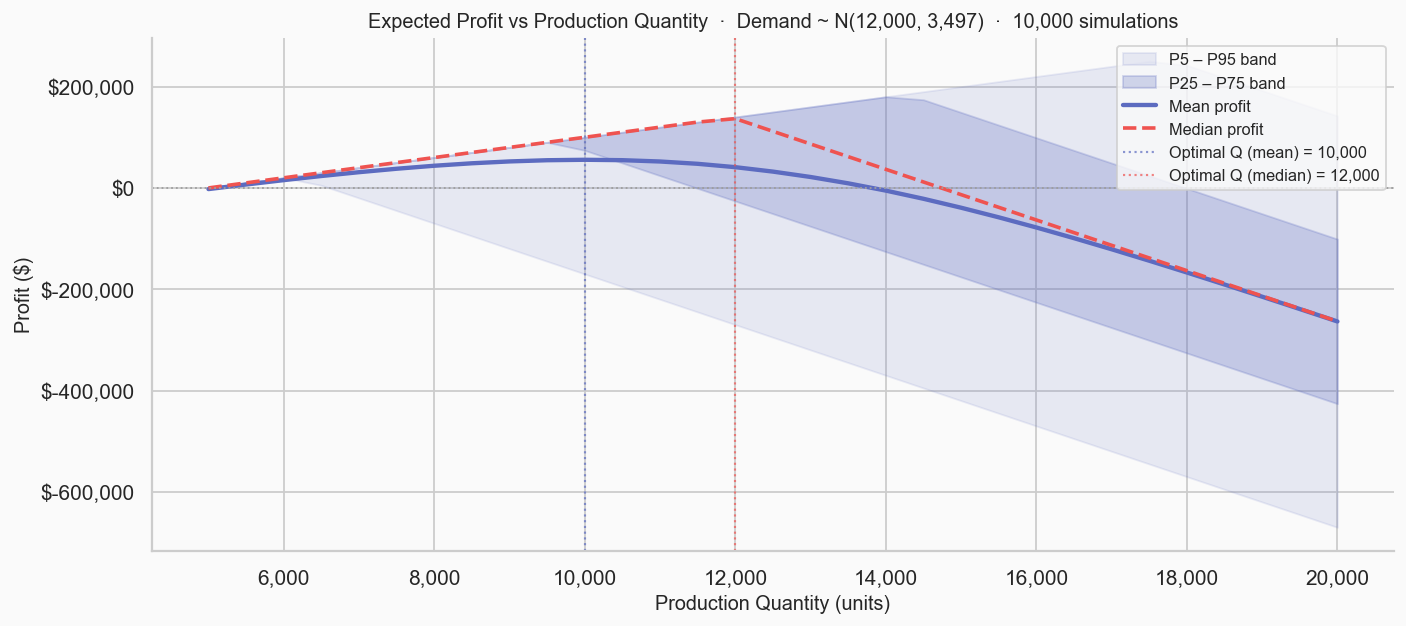

In [ ]:
# ── Figure 1 · Mean & Median Profit vs Production Quantity ───────────────────
fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

ax.fill_between(results["Q"], results["p5"], results["p95"],
                alpha=0.12, color="#5C6BC0", label="P5 – P95 band")
ax.fill_between(results["Q"], results["p25"], results["p75"],
                alpha=0.25, color="#5C6BC0", label="P25 – P75 band")

ax.plot(results["Q"], results["mean"],   color="#5C6BC0", lw=2.4, label="Mean profit")
ax.plot(results["Q"], results["median"], color="#EF5350", lw=2,
        linestyle="--", label="Median profit")

ax.axhline(0, color="#9E9E9E", lw=1, linestyle=":")

# Mark optima
ax.axvline(best_mean, color="#5C6BC0", lw=1.2, linestyle=":",
           alpha=0.7, label=f"Optimal Q (mean) = {best_mean:,.0f}")
ax.axvline(best_median, color="#EF5350", lw=1.2, linestyle=":",
           alpha=0.7, label=f"Optimal Q (median) = {best_median:,.0f}")

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_xlabel("Production Quantity (units)", fontsize=11)
ax.set_ylabel("Profit ($)", fontsize=11)
ax.set_title(
    f"Expected Profit vs Production Quantity  ·  "
    f"Demand ~ N({MEAN_DEMAND:,}, {STDEV_DEMAND:,})  ·  {N_SIMS:,} simulations",
    fontsize=11,
)
ax.legend(fontsize=9, loc="upper right")
plt.tight_layout()
# plt.savefig("profit_vs_Q.png", dpi=150, bbox_inches="tight", facecolor="#FAFAFA")
plt.show()


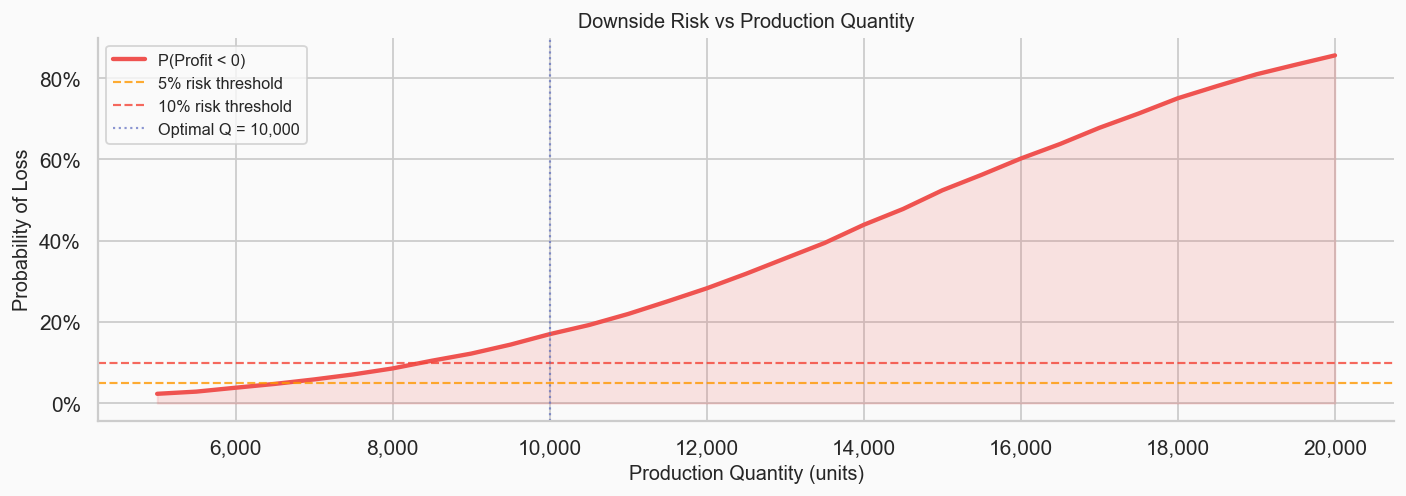

In [ ]:
# ── Figure 2 · Probability of Loss vs Production Quantity ────────────────────
fig, ax = plt.subplots(figsize=(11, 4))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

ax.plot(results["Q"], results["prob_loss"] * 100,
        color="#EF5350", lw=2.4, label="P(Profit < 0)")

# Shade the risk zone
ax.fill_between(results["Q"], results["prob_loss"] * 100, 0,
                alpha=0.15, color="#EF5350")

ax.axhline(5,  color="#FF9800", lw=1.2, linestyle="--", alpha=0.8, label="5% risk threshold")
ax.axhline(10, color="#F44336", lw=1.2, linestyle="--", alpha=0.8, label="10% risk threshold")
ax.axvline(best_mean, color="#5C6BC0", lw=1.2, linestyle=":",
           alpha=0.7, label=f"Optimal Q = {best_mean:,.0f}")

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_xlabel("Production Quantity (units)", fontsize=11)
ax.set_ylabel("Probability of Loss", fontsize=11)
ax.set_title("Downside Risk vs Production Quantity", fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
# plt.savefig("prob_loss_vs_Q.png", dpi=150, bbox_inches="tight", facecolor="#FAFAFA")
plt.show()


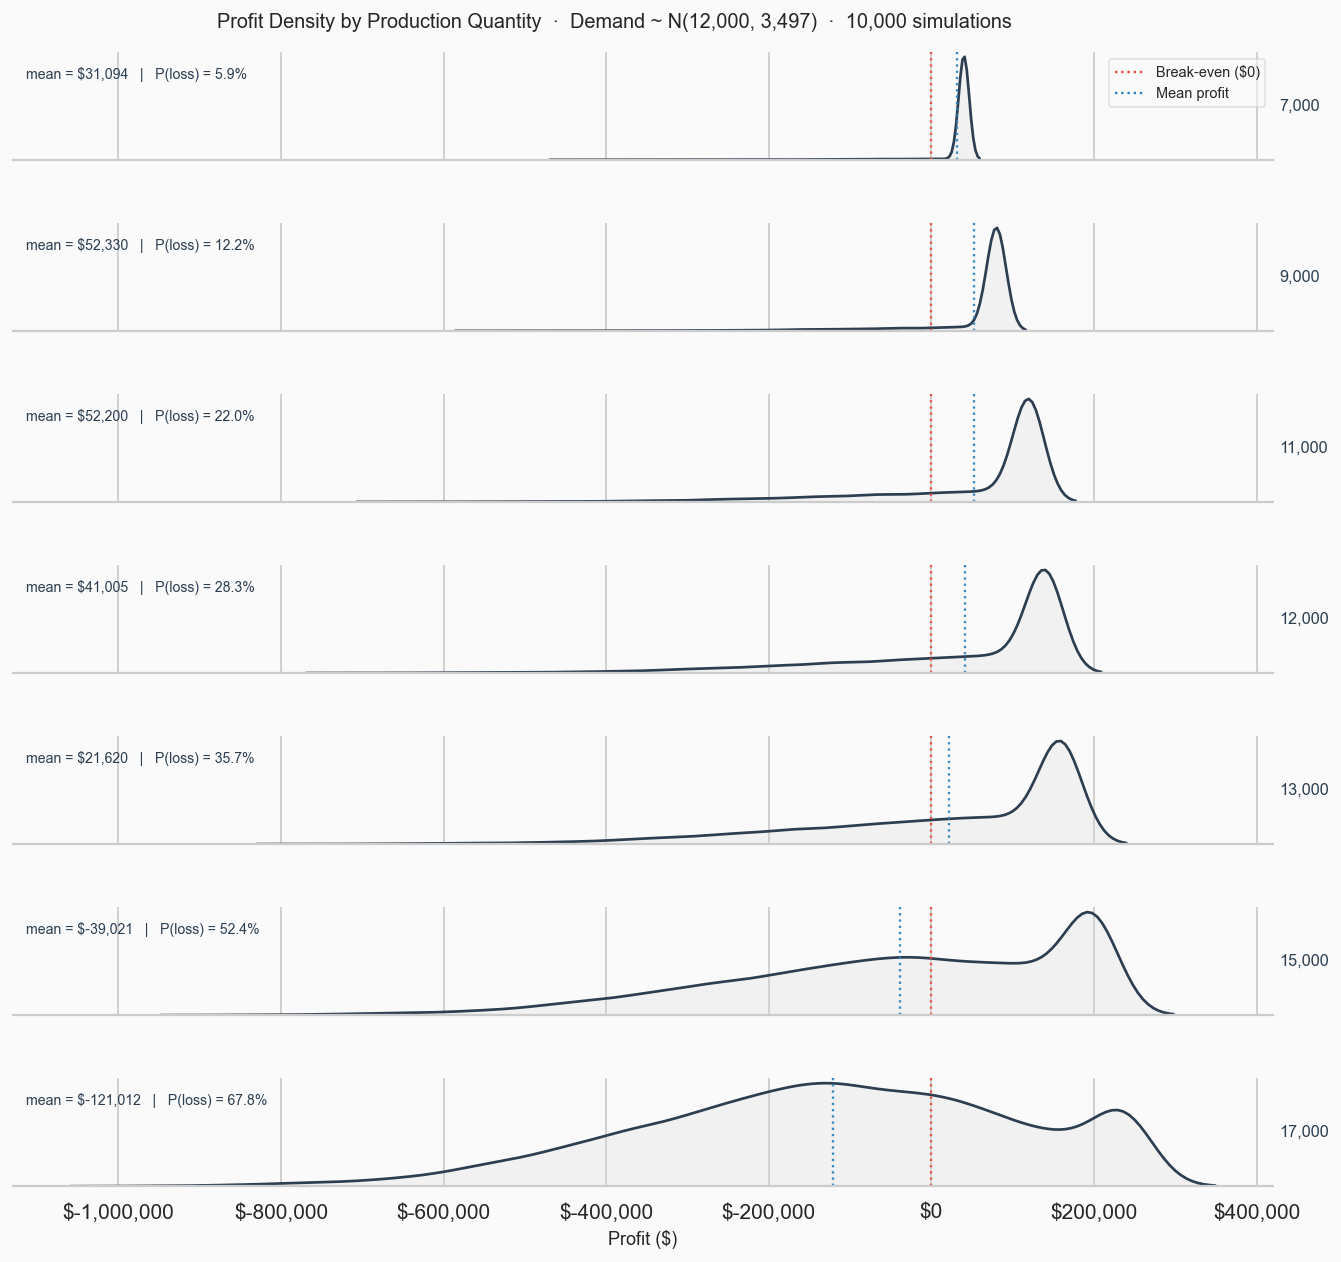

In [14]:
# ── Faceted Density Plot (seaborn) · Profit by Production Quantity ────────────
from matplotlib.lines import Line2D

selected_Q = [7_000, 9_000, 11_000, 12_000, 13_000, 15_000, 17_000]

# Build long-form DataFrame for seaborn
df_facet = (
    pd.DataFrame({Q: np.array(simulate_profit(Q, demand_draws)) for Q in selected_Q})
    .melt(var_name="Q", value_name="profit")
    .assign(Q=lambda df: pd.Categorical(
        df["Q"].astype(int),
        categories=[int(q) for q in selected_Q],
        ordered=True
    ))
)

LINE_COLOR = "#2C3E50"
FILL_COLOR = "#DADADA"

g = sns.FacetGrid(
    df_facet, row="Q", height=1.4, aspect=7.5,
    sharex=True, sharey=False,
)

# Control spacing directly on the figure after creation
g.figure.subplots_adjust(hspace=0.08, top=0.96, bottom=0.07)

g.map(sns.kdeplot, "profit",
      fill=True, color=FILL_COLOR, linewidth=0)
g.map(sns.kdeplot, "profit",
      fill=False, color=LINE_COLOR, linewidth=1.5)

for ax, Q in zip(g.axes.flat, selected_Q):
    data = df_facet.query("Q == @Q")["profit"].to_numpy()
    mean_p    = data.mean()
    prob_loss = (data < 0).mean()

    ax.axvline(0,      color="#E74C3C", lw=1.3, linestyle=":", alpha=0.9)
    ax.axvline(mean_p, color="#2980B9", lw=1.3, linestyle=":", alpha=0.9)

    ax.set_ylabel(""); ax.set_yticks([])
    ax.set_xlabel("")
    ax.tick_params(left=False)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.set_facecolor("#FAFAFA")

    ax.text(1.005, 0.5, f"{Q:,}", transform=ax.transAxes,
            va="center", ha="left", fontsize=9, color=LINE_COLOR)
    ax.text(0.01, 0.75,
            f"mean = ${mean_p:,.0f}   |   P(loss) = {prob_loss:.1%}",
            transform=ax.transAxes, fontsize=7.8, color=LINE_COLOR)

g.axes.flat[-1].set_xlabel("Profit ($)", fontsize=10)
g.axes.flat[-1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

g.set_titles("")

legend_elements = [
    Line2D([0],[0], color="#E74C3C", lw=1.3, linestyle=":", label="Break-even ($0)"),
    Line2D([0],[0], color="#2980B9", lw=1.3, linestyle=":", label="Mean profit"),
]
g.axes.flat[0].legend(handles=legend_elements, fontsize=8,
                      loc="upper right", framealpha=0.5)

g.figure.patch.set_facecolor("#FAFAFA")
g.figure.suptitle(
    f"Profit Density by Production Quantity  ·  "
    f"Demand ~ N({MEAN_DEMAND:,}, {STDEV_DEMAND:,})  ·  {N_SIMS:,} simulations",
    fontsize=11, y=0.99,
)
plt.show()

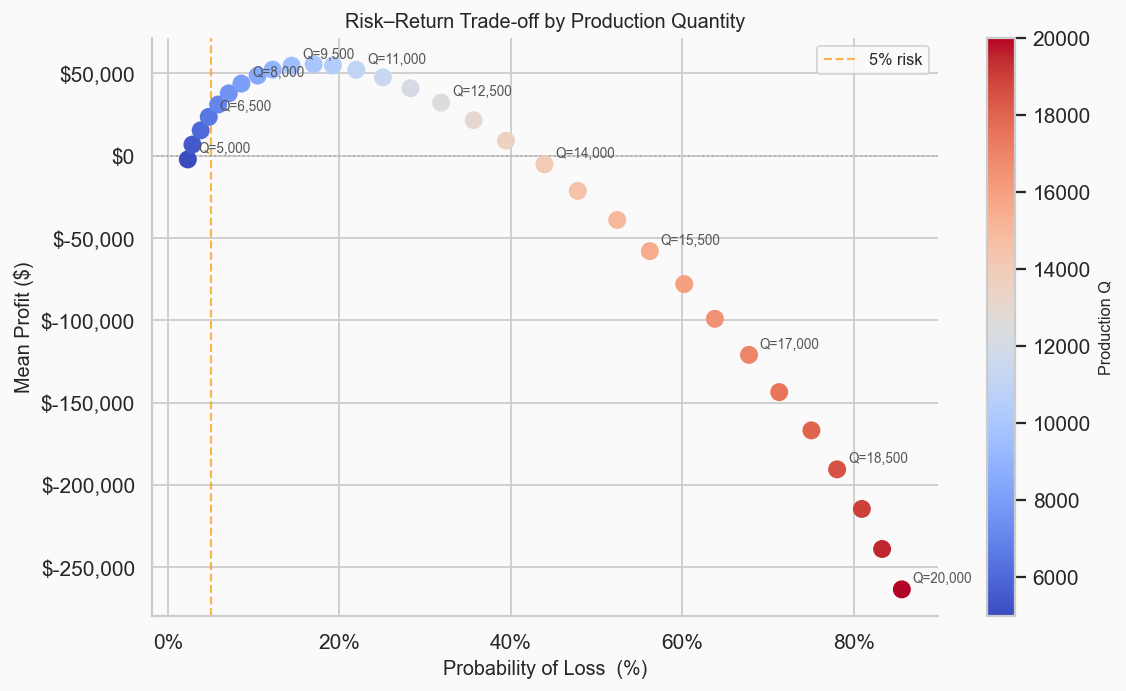

In [ ]:
# ── Figure 5 · Risk–Return Scatter ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

sc = ax.scatter(
    results["prob_loss"] * 100,
    results["mean"],
    c=results["Q"],
    cmap="coolwarm",
    s=80,
    zorder=3,
)

# Annotate every 3rd point
for _, row in results.iloc[::3].iterrows():
    ax.annotate(f"Q={row['Q']:,.0f}",
                (row["prob_loss"]*100, row["mean"]),
                textcoords="offset points", xytext=(6, 4),
                fontsize=7.5, color="#555")

cb = plt.colorbar(sc, ax=ax)
cb.set_label("Production Q", fontsize=9)

ax.axvline(5, color="#FF9800", lw=1.2, linestyle="--", alpha=0.7, label="5% risk")
ax.axhline(0, color="#9E9E9E", lw=1,   linestyle=":",  alpha=0.7)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_xlabel("Probability of Loss  (%)", fontsize=11)
ax.set_ylabel("Mean Profit ($)", fontsize=11)
ax.set_title("Risk–Return Trade-off by Production Quantity", fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
# plt.savefig("risk_return.png", dpi=150, bbox_inches="tight", facecolor="#FAFAFA")
plt.show()


In [16]:
# ── Decision summary ─────────────────────────────────────────────────────────
best_row   = results.loc[results["mean"].idxmax()]
safe_Q_row = results.loc[(results["prob_loss"] <= 0.05)
                          .idxmax() if (results["prob_loss"] <= 0.05).any()
                          else results["prob_loss"].idxmin()]

print("=" * 55)
print("  DECISION SUMMARY")
print("=" * 55)
print(f"  Profit-maximising Q    : {best_row['Q']:>8,.0f} units")
print(f"    → Mean profit        : ${best_row['mean']:>10,.0f}")
print(f"    → P(loss)            : {best_row['prob_loss']:>9.1%}")
print()
print(f"  Risk-minimising Q (≤5% loss) : {safe_Q_row['Q']:>6,.0f} units")
print(f"    → Mean profit              : ${safe_Q_row['mean']:>10,.0f}")
print(f"    → P(loss)                  : {safe_Q_row['prob_loss']:>9.1%}")
print("=" * 55)


  DECISION SUMMARY
  Profit-maximising Q    :   10,000 units
    → Mean profit        : $    55,582
    → P(loss)            :     17.0%

  Risk-minimising Q (≤5% loss) :  5,000 units
    → Mean profit              : $    -2,273
    → P(loss)                  :      2.3%
